In [ ]:
#Cell 1 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set working directory
os.chdir('/Users/niravparmar/retail-fraud-detection')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')
print("Ready.")

Ready.


In [2]:
#Cell 2 Load Data 

print("Loading data...")
train_tx = pd.read_csv('data/raw/train_transaction.csv')
train_id = pd.read_csv('data/raw/train_identity.csv')

# Merge transaction + identity on TransactionID
df = train_tx.merge(train_id, on='TransactionID', how='left')

print(f"Merged shape: {df.shape}")
print(f"Fraud rate:   {df['isFraud'].mean()*100:.2f}%")

Loading data...
Merged shape: (590540, 434)
Fraud rate:   3.50%


Time features created:
  hour, day_of_week, day_of_month, week, is_night, is_weekend


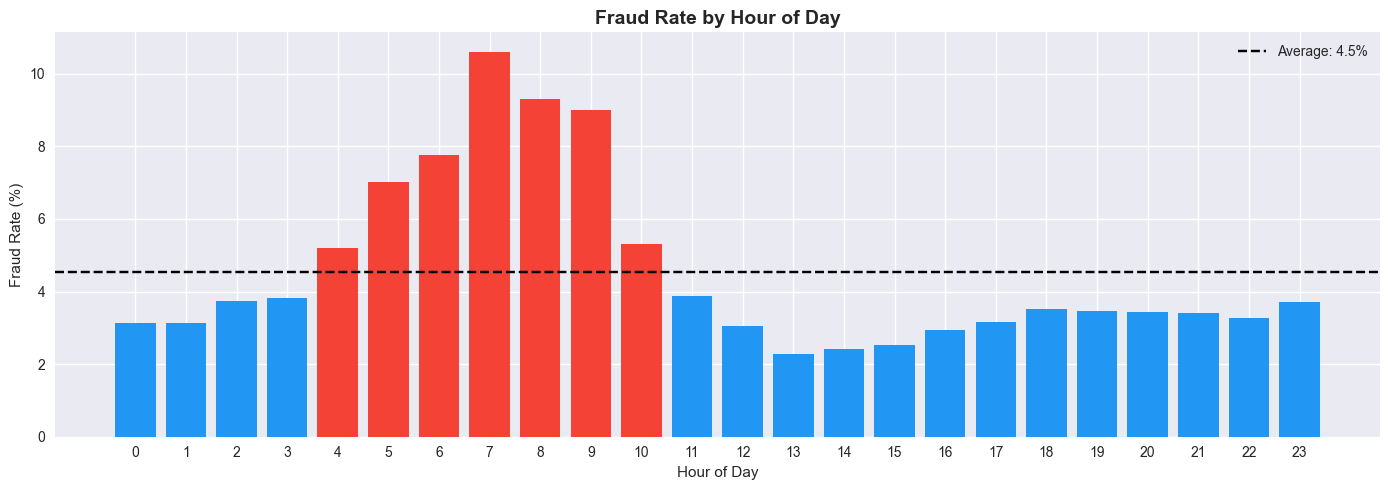


Peak fraud hour: 7:00 (10.61% fraud rate)


In [3]:
#Cell 3 — Time-based features:

# TransactionDT is seconds offset from a reference time
# Extract meaningful time features from it

df['hour']        = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['day_of_month']= (df['TransactionDT'] // (3600 * 24)) % 30
df['week']        = (df['TransactionDT'] // (3600 * 24 * 7)) % 52

# Is it a night transaction? (midnight to 6am = higher fraud risk)
df['is_night']    = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)

# Is it a weekend?
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

print("Time features created:")
print(f"  hour, day_of_week, day_of_month, week, is_night, is_weekend")

# Visualise fraud by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100

plt.figure(figsize=(14, 5))
plt.bar(hourly_fraud.index, hourly_fraud.values, 
        color=['#F44336' if x > hourly_fraud.mean() else '#2196F3' 
               for x in hourly_fraud.values])
plt.axhline(y=hourly_fraud.mean(), color='black', 
            linestyle='--', label=f'Average: {hourly_fraud.mean():.1f}%')
plt.title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('reports/figures/06_fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_fraud.idxmax()
print(f"\nPeak fraud hour: {peak_hour}:00 ({hourly_fraud[peak_hour]:.2f}% fraud rate)")

In [ ]:
#Cell 4 — Transaction velocity features:

# How many transactions has this card made recently?
# Fraudsters make multiple transactions in short windows

print("Building velocity features — this takes ~2 minutes...")

# Sort by card and time
df = df.sort_values(['card1', 'TransactionDT'])

# Transaction count per card in last N transactions
df['card1_count'] = df.groupby('card1')['card1'].transform('count')

# Mean and std of transaction amount per card
df['card1_amt_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_amt_std']  = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

# How different is this transaction from card's usual amount?
df['amt_deviation'] = (df['TransactionAmt'] - df['card1_amt_mean']) / (df['card1_amt_std'] + 1)

# Transaction count per email domain
df['email_count'] = df.groupby('P_emaildomain')['TransactionID'].transform('count')

# Fraud rate per email domain (target encoding)
email_fraud = df.groupby('P_emaildomain')['isFraud'].mean()
df['email_fraud_rate'] = df['P_emaildomain'].map(email_fraud)

print("Velocity features created:")
print("  card1_count, card1_amt_mean, card1_amt_std")
print("  amt_deviation, email_count, email_fraud_rate")

# Show top suspicious cards
print(f"\nCards with highest transaction counts:")
print(df.groupby('card1')['card1_count'].first().sort_values(ascending=False).head(10))